In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading in data

In [75]:
exponential_fit = pd.read_csv("../../../output/GCN4_pipeline/speed/exponential_fit.csv", index_col = 0)
exponential_fit = exponential_fit[["ADseq", "A+C", "k"]]
exponential_fit = exponential_fit.rename(columns = {"A+C" : "strength", 
                                                    "k" : "speed"})
exponential_fit

,ADseq,strength,speed
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.986402,0.074620
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.129853,0.146610
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.706721,0.159460
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.630930,0.155566
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,3.971689,0.155898
...,...,...,...
1703,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,1.421365,0.151502
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,2.168666,0.059275
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,5.164379,0.185546
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,3.055855,0.160765


Text(0.5, 1.05, 'GCN4 Exponential Fits')

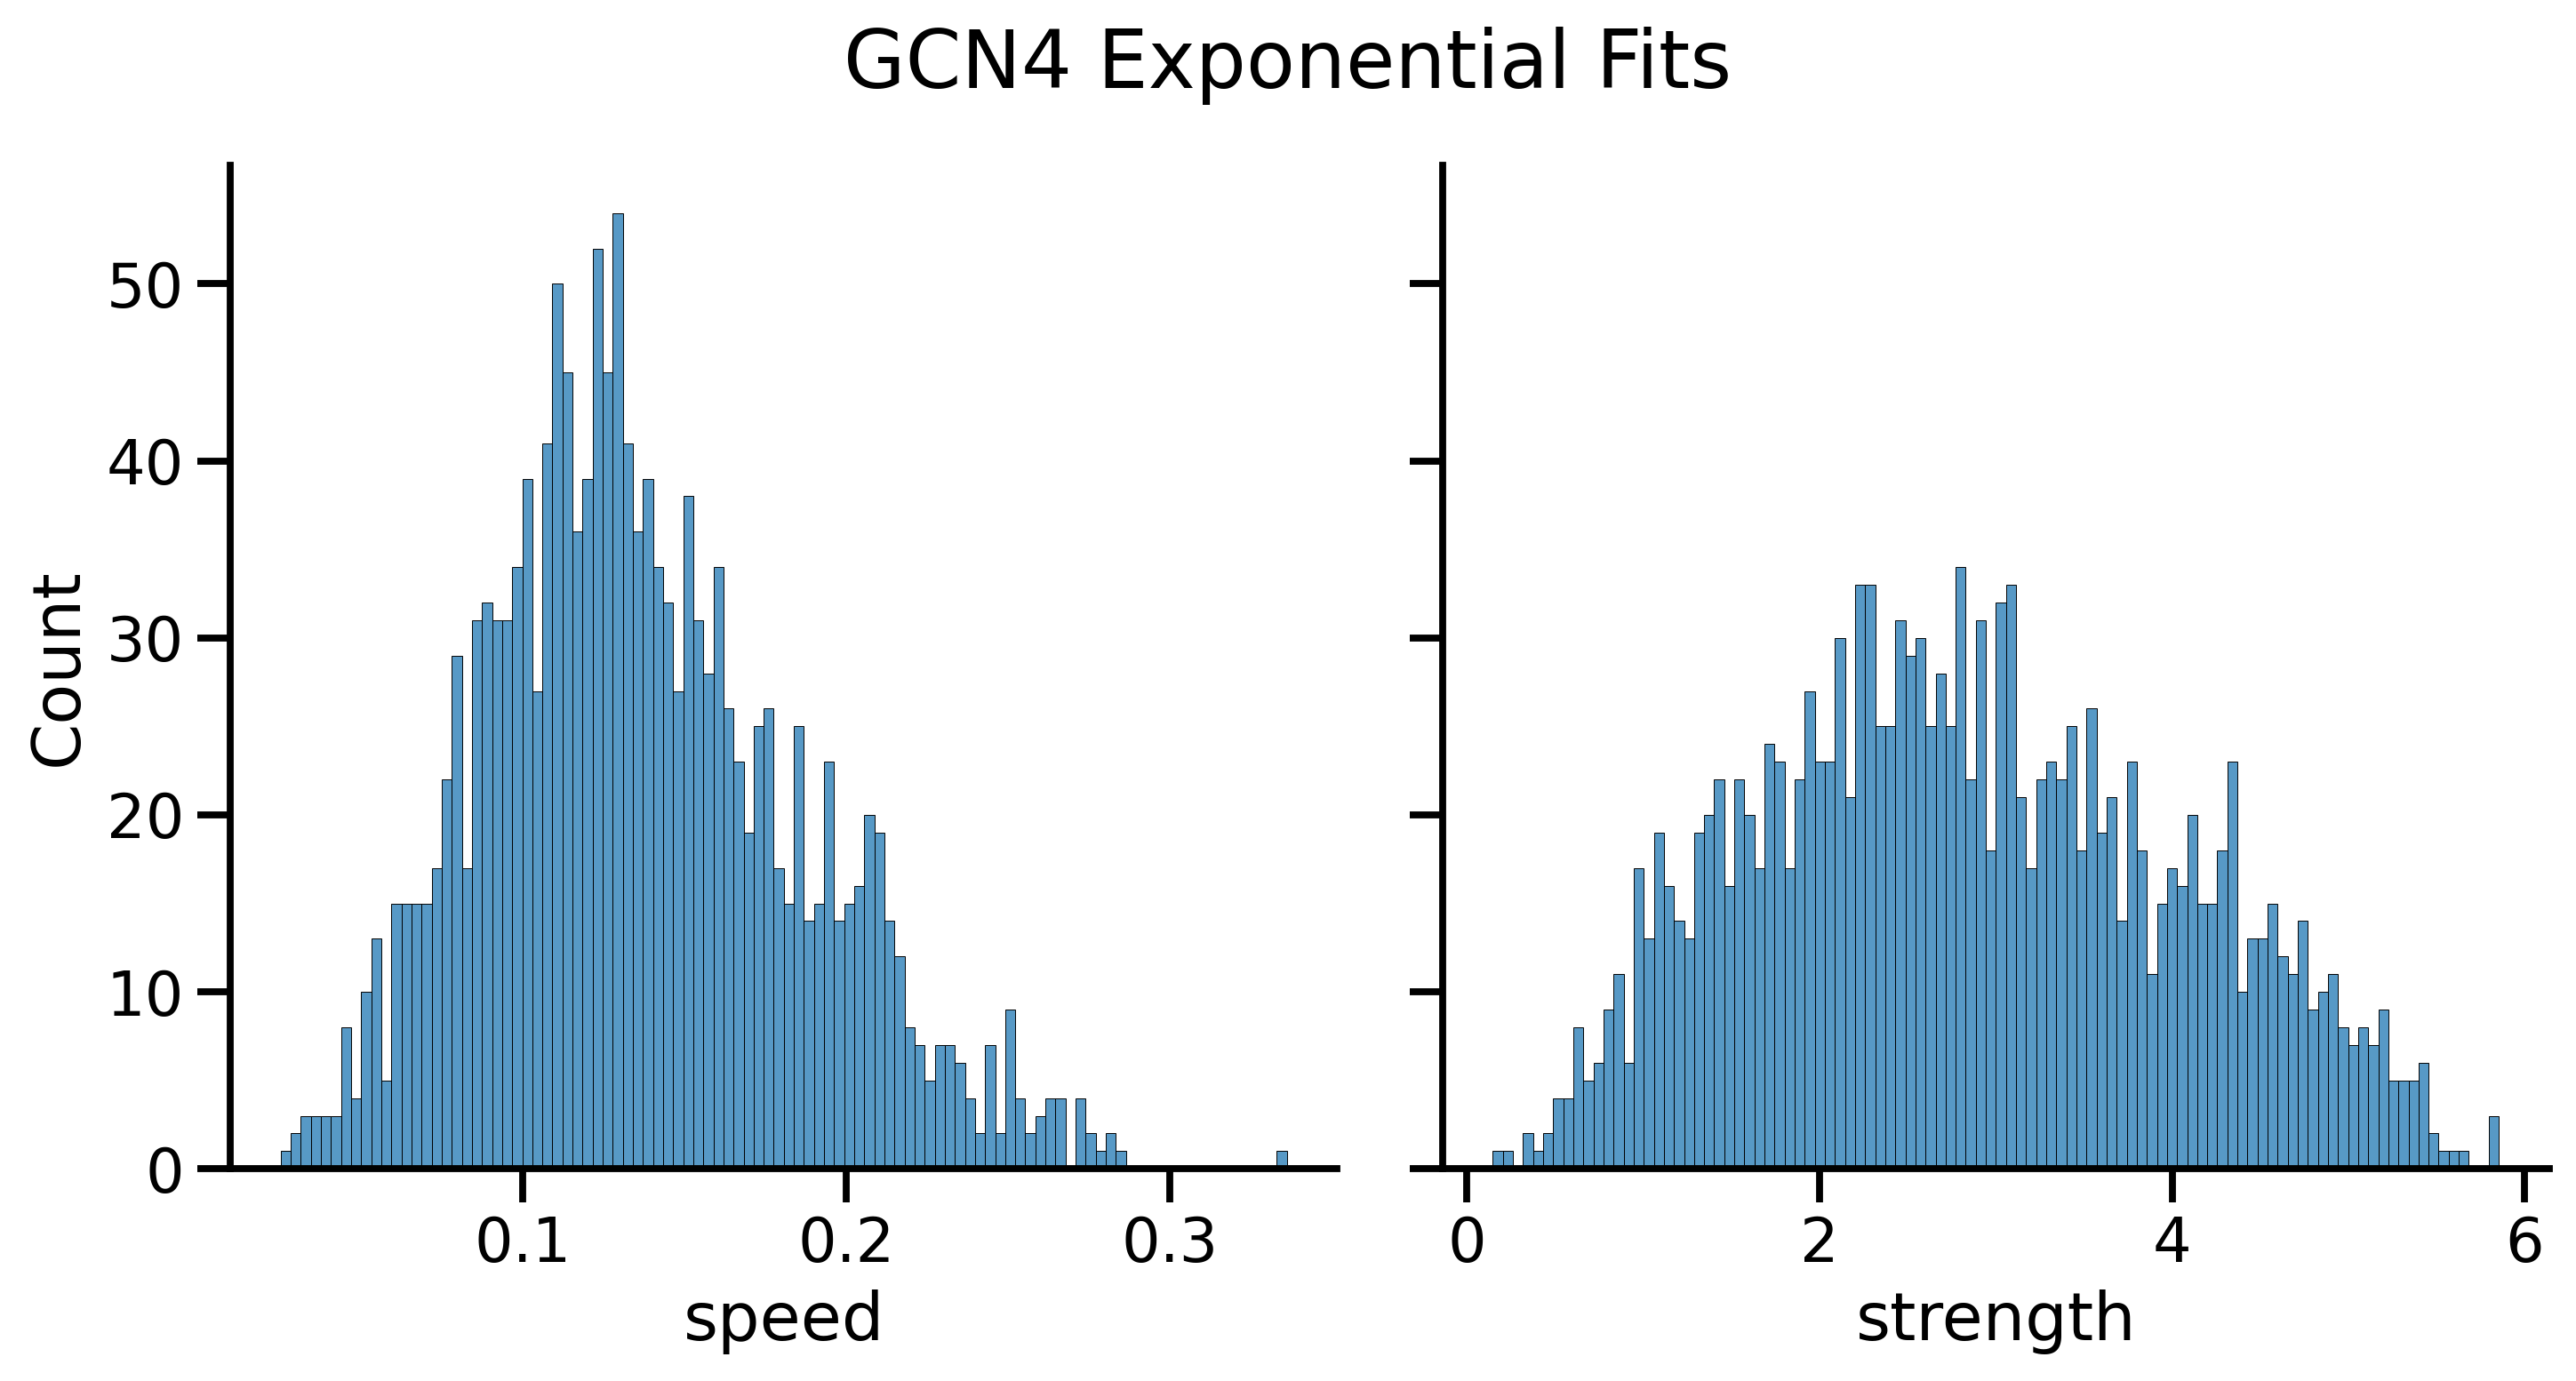

In [77]:
fig,axs = plt.subplots(1, 2, dpi = 300, figsize = (10,5), sharey = True)
sns.histplot(exponential_fit["speed"], ax = axs[0], bins = 100)
sns.histplot(exponential_fit["strength"], ax = axs[1], bins = 100)
sns.despine()
plt.tight_layout()
fig.suptitle("GCN4 Exponential Fits", y = 1.05)

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. Build amino-acid count features
# =========================================================
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_counts(seq):
    c = Counter(seq)
    return [c.get(aa, 0) for aa in AMINO_ACIDS]

X = pd.DataFrame(
    exponential_fit["ADseq"].apply(aa_counts).tolist(),
    columns=AMINO_ACIDS
)

y_speed = exponential_fit["speed"].values
y_strength = exponential_fit["strength"].values

# =========================================================
# 2. Helper function
# =========================================================
def evaluate_linear(X, y, target_name):
    # Hold-out split for final visualization / sanity check
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Fit ordinary linear regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Test-set prediction
    y_test_pred = model.predict(X_test)

    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_r, _ = pearsonr(y_test, y_test_pred)

    print(f"\n=== {target_name} ===")
    print(f"Test R^2:   {test_r2:.3f}")
    print(f"Test RMSE:  {test_rmse:.3f}")
    print(f"Test r:     {test_r:.3f}")

    coef_df = pd.DataFrame({
        "AA": X.columns,
        "coef": model.coef_
    }).sort_values("coef", key=abs, ascending=False)

    print("\nTop 10 coefficients by |value|:")
    print(coef_df.head(10).to_string(index=False))

    # 5-fold CV predictions on the full dataset
    cv_model = LinearRegression()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_cv_pred = cross_val_predict(cv_model, X, y, cv=kf)

    cv_r2 = r2_score(y, y_cv_pred)
    cv_rmse = mean_squared_error(y, y_cv_pred) ** 0.5
    cv_r, _ = pearsonr(y, y_cv_pred)

    print("\n5-fold CV performance:")
    print(f"CV R^2:     {cv_r2:.3f}")
    print(f"CV RMSE:    {cv_rmse:.3f}")
    print(f"CV r:       {cv_r:.3f}")

    return {
        "model": model,
        "coef_df": coef_df,
        "X_test": X_test,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_cv_pred": y_cv_pred,
    }

# =========================================================
# 3. Run models
# =========================================================
y_speed_z = (y_speed - y_speed.mean()) / y_speed.std()
y_strength_z = (y_strength - y_strength.mean()) / y_strength.std()

speed_results = evaluate_linear(X, y_speed_z, "SPEED (z-scored)")
strength_results = evaluate_linear(X, y_strength_z, "STRENGTH (z-scored)")


=== SPEED (z-scored) ===
Test R^2:   0.241
Test RMSE:  0.868
Test r:     0.503

Top 10 coefficients by |value|:
AA      coef
 W  0.341945
 C -0.297333
 F  0.225810
 R -0.196877
 D  0.145437
 M  0.130530
 K -0.078723
 G -0.052629
 V -0.048127
 H -0.046499

5-fold CV performance:
CV R^2:     0.308
CV RMSE:    0.832
CV r:       0.555

=== STRENGTH (z-scored) ===
Test R^2:   0.614
Test RMSE:  0.634
Test r:     0.784

Top 10 coefficients by |value|:
AA      coef
 W  0.506395
 R -0.310749
 F  0.296494
 K -0.262977
 M  0.203412
 L  0.156148
 H -0.153015
 Q -0.140004
 G -0.123595
 I  0.115520

5-fold CV performance:
CV R^2:     0.583
CV RMSE:    0.646
CV r:       0.763


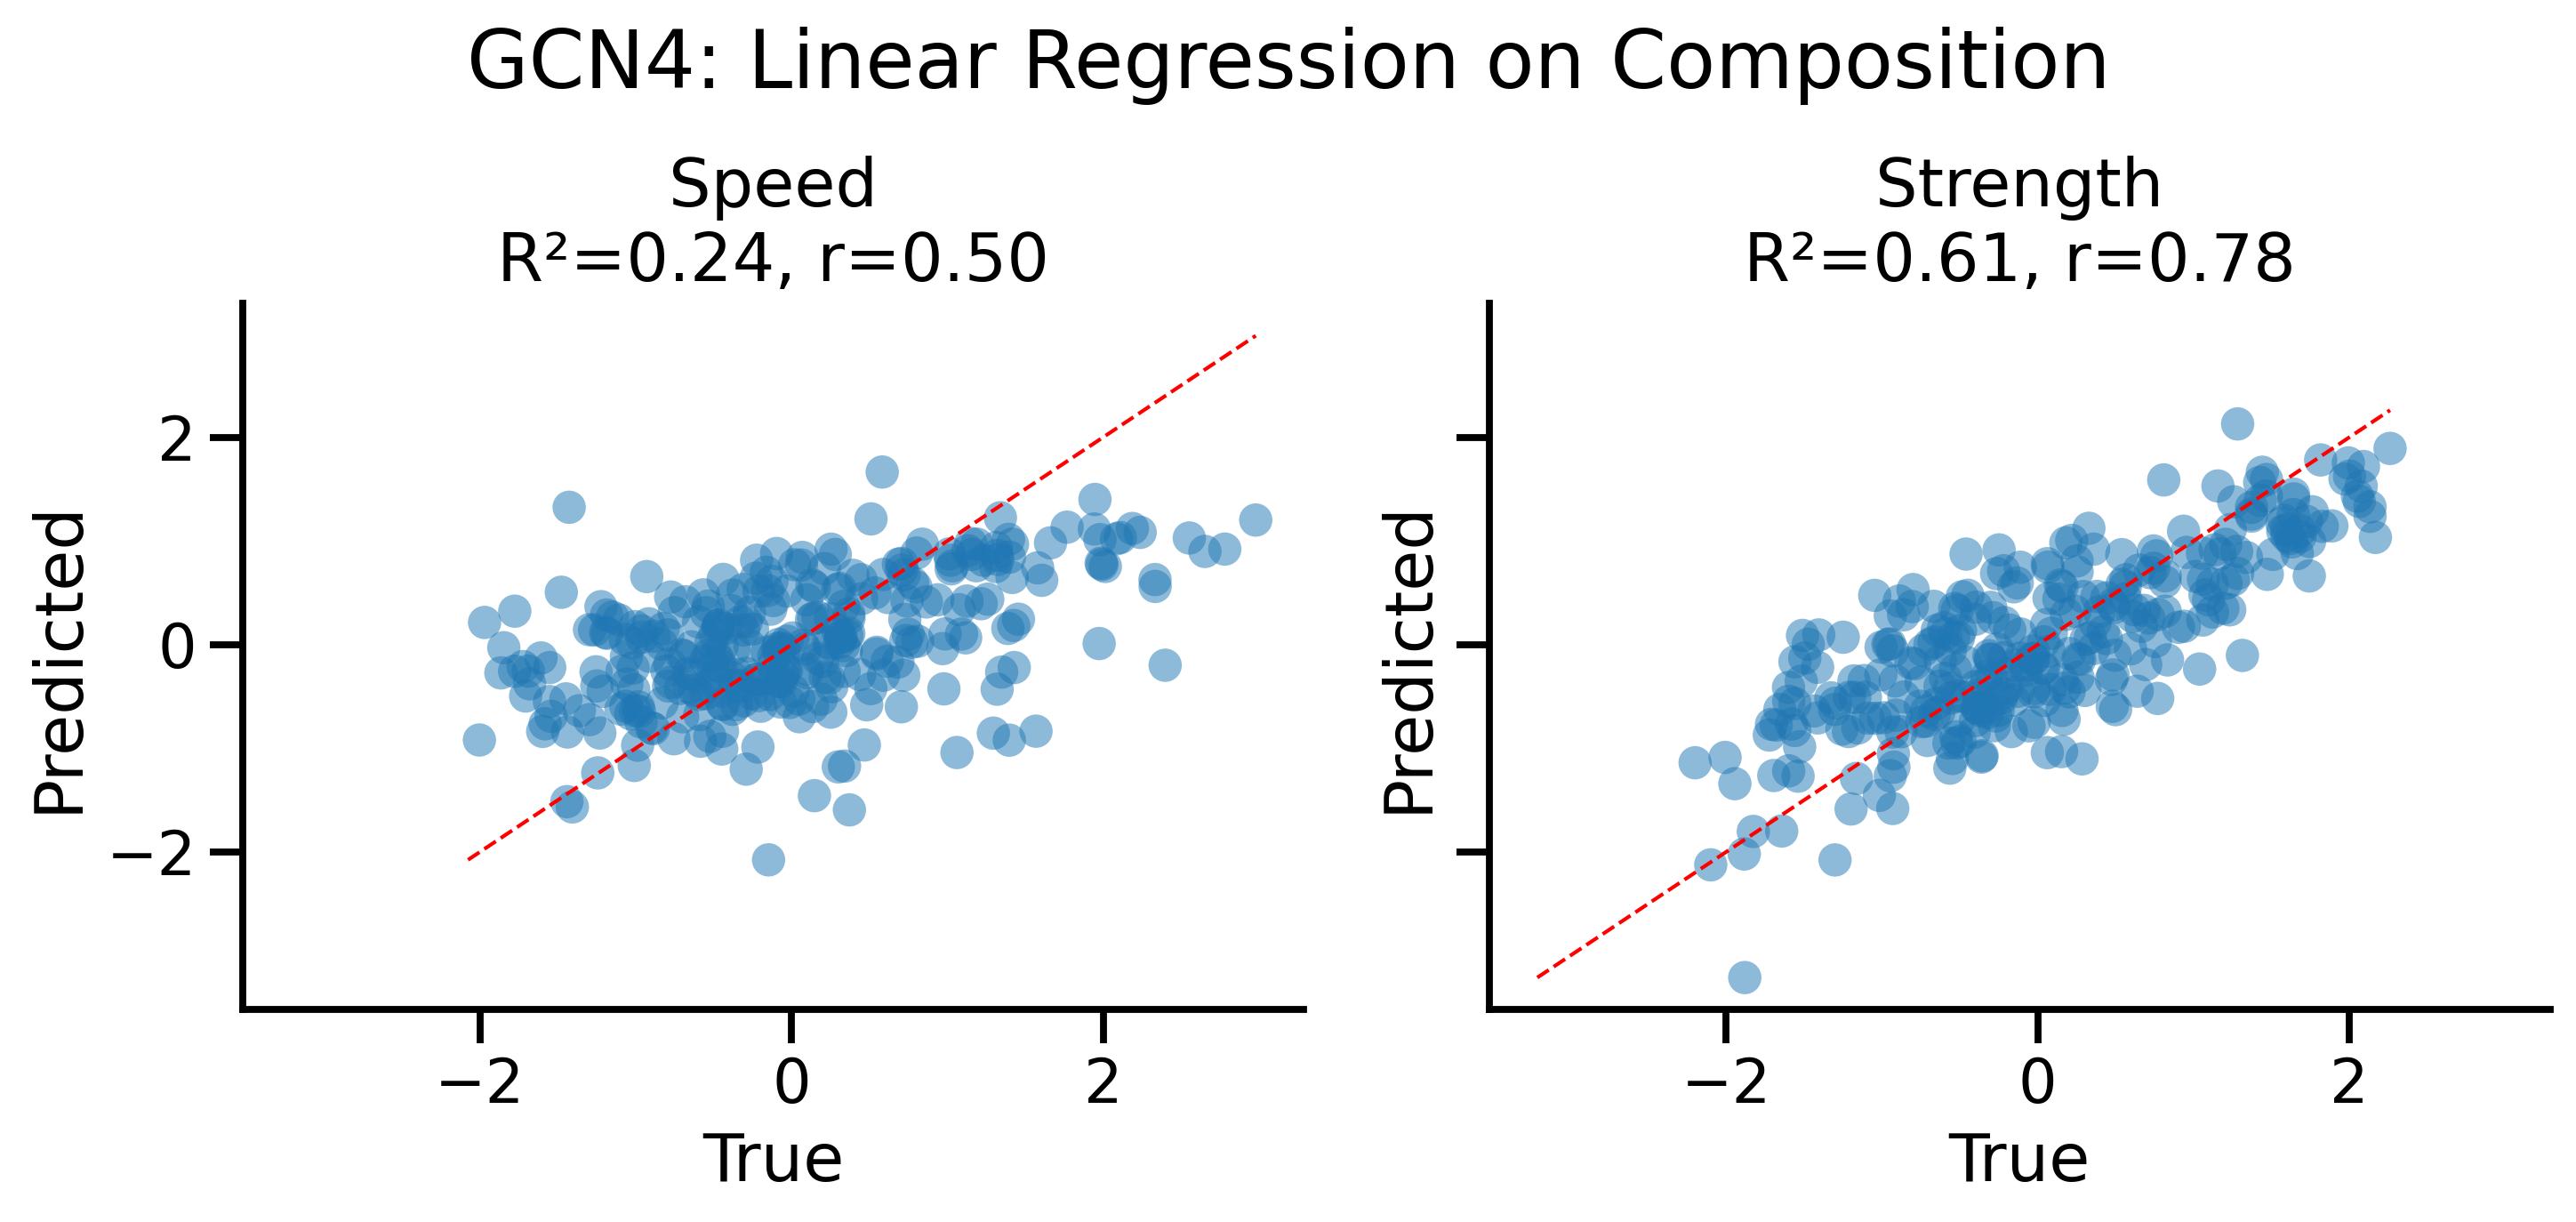

In [156]:
# =========================================================
# 4. Plot test-set predictions
# =========================================================
sns.set_context('talk')

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi = 300, sharey = True, sharex = True)

for ax, results, title in zip(
    axes,
    [speed_results, strength_results],
    ["Speed", "Strength"]
):
    y_true = results["y_test"]
    y_pred = results["y_test_pred"]

    ax.scatter(y_true, y_pred, alpha=0.5, edgecolors="none")
    lims = [
        min(np.min(y_true), np.min(y_pred)),
        max(np.max(y_true), np.max(y_pred))
    ]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    r = pearsonr(y_true, y_pred)[0]
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{title}\nR²={r2:.2f}, r={r:.2f}")

sns.despine()

fig.suptitle("GCN4: Linear Regression on Composition", y = 0.93)
plt.tight_layout()
plt.show()

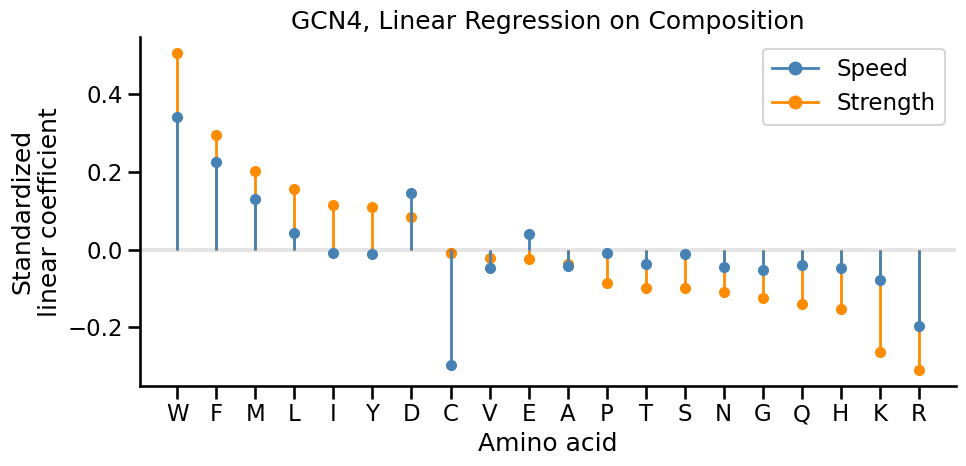

In [159]:
from matplotlib.lines import Line2D

speed_coef = speed_results["coef_df"].set_index("AA").loc[AMINO_ACIDS]["coef"]
strength_coef = strength_results["coef_df"].set_index("AA").loc[AMINO_ACIDS]["coef"]

coef_summary = pd.DataFrame({
    "speed": speed_coef,
    "strength": strength_coef
}, index=AMINO_ACIDS)

# Sort by strength coefficient
coef_summary = coef_summary.sort_values("strength", ascending=False)

x = np.arange(len(coef_summary))

plt.figure(figsize=(10, 5))

m1, s1, _ = plt.stem(
    x, coef_summary["speed"],
    linefmt="steelblue", markerfmt="o", basefmt=" "
)
plt.setp(s1, linewidth=2, color="steelblue", zorder = 10)
plt.setp(m1, markersize=7, markerfacecolor="steelblue", markeredgecolor="steelblue", zorder = 10)

m2, s2, _ = plt.stem(
    x, coef_summary["strength"],
    linefmt="darkorange", markerfmt="o", basefmt=" "
)
plt.setp(s2, linewidth=2, color="darkorange")
plt.setp(m2, markersize=7, markerfacecolor="darkorange", markeredgecolor="darkorange")

plt.axhline(0, color="black", lw=3, alpha = 0.1)
plt.xticks(x, coef_summary.index)
plt.xlabel("Amino acid")
plt.ylabel("Standardized\nlinear coefficient")
plt.title("GCN4, Linear Regression on Composition")

legend_elements = [
    Line2D([0], [0], color="steelblue", marker="o", lw=2, label="Speed"),
    Line2D([0], [0], color="darkorange", marker="o", lw=2, label="Strength"),
]
plt.legend(handles=legend_elements)

plt.tight_layout()
sns.despine()
plt.show()

# Ridge regression on amino acid composition

This analysis asks whether **amino acid composition alone** can explain variation in the measured **speed** and **strength** of each sequence. Each sequence is converted into a 20-dimensional feature vector containing the counts of the standard amino acids (`A–Y`), so the model uses only overall composition and not sequence order or patterning.

To compare the two traits on the same scale, both **speed** and **strength** are first **z-scored**. A separate **ridge regression** model is then fit for each target. Ridge regression is a regularized version of linear regression that shrinks coefficients toward zero, which is useful here because amino acid counts are correlated with one another. The regularization strength (`alpha`) is selected by 5-fold cross-validation using `RidgeCV`.

Model performance is evaluated in two ways:  
1. an **80/20 train-test split** for a simple held-out test set estimate, and  
2. **5-fold cross-validation** across the full dataset for a more robust measure of predictive performance.  

For each model, the code reports:
- the best `alpha`
- test-set **R²**, **RMSE**, and **Pearson correlation**
- cross-validated **R²**, **RMSE**, and **Pearson correlation**
- the top amino acid coefficients ranked by absolute magnitude

Because the targets are z-scored, the fitted coefficients can be compared between the speed and strength models. Positive coefficients indicate amino acids associated with higher predicted values of the trait, while negative coefficients indicate amino acids associated with lower predicted values.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from scipy.stats import pearsonr

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. Build amino-acid count features
# =========================================================
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_counts(seq):
    c = Counter(seq)
    return [c.get(aa, 0) for aa in AMINO_ACIDS]

X = pd.DataFrame(
    exponential_fit["ADseq"].apply(aa_counts).tolist(),
    columns=AMINO_ACIDS
)

y_speed = exponential_fit["speed"].values
y_strength = exponential_fit["strength"].values

# =========================================================
# 2. Helper function
# =========================================================
def evaluate_ridge(X, y, target_name, alphas=None):
    if alphas is None:
        alphas = np.logspace(-3, 3, 50)

    # Hold-out split for final visualization / sanity check
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Cross-validated model selection on training set
    model = RidgeCV(alphas=alphas, cv=5)
    model.fit(X_train, y_train)

    # Test-set prediction
    y_test_pred = model.predict(X_test)

    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_r, _ = pearsonr(y_test, y_test_pred)

    print(f"\n=== {target_name} ===")
    print(f"Best alpha: {model.alpha_:.5f}")
    print(f"Test R^2:   {test_r2:.3f}")
    print(f"Test RMSE:  {test_rmse:.3f}")
    print(f"Test r:     {test_r:.3f}")

    coef_df = pd.DataFrame({
        "AA": X.columns,
        "coef": model.coef_
    }).sort_values("coef", key=abs, ascending=False)

    print("\nTop 10 coefficients by |value|:")
    print(coef_df.head(10).to_string(index=False))

    # 5-fold CV predictions on the full dataset
    cv_model = RidgeCV(alphas=alphas, cv=5)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_cv_pred = cross_val_predict(cv_model, X, y, cv=kf)

    cv_r2 = r2_score(y, y_cv_pred)
    cv_rmse = mean_squared_error(y, y_cv_pred) ** 0.5
    cv_r, _ = pearsonr(y, y_cv_pred)

    print("\n5-fold CV performance:")
    print(f"CV R^2:     {cv_r2:.3f}")
    print(f"CV RMSE:    {cv_rmse:.3f}")
    print(f"CV r:       {cv_r:.3f}")

    return {
        "model": model,
        "coef_df": coef_df,
        "X_test": X_test,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_cv_pred": y_cv_pred,
    }

# =========================================================
# 3. Run models
# =========================================================
y_speed_z = (y_speed - y_speed.mean()) / y_speed.std()
y_strength_z = (y_strength - y_strength.mean()) / y_strength.std()

speed_results = evaluate_ridge(X, y_speed_z, "SPEED (z-scored)")
strength_results = evaluate_ridge(X, y_strength_z, "STRENGTH (z-scored)")


=== SPEED (z-scored) ===
Best alpha: 25.59548
Test R^2:   0.244
Test RMSE:  0.867
Test r:     0.503

Top 10 coefficients by |value|:
AA      coef
 W  0.304402
 C -0.253857
 F  0.218684
 R -0.193847
 D  0.149350
 M  0.121778
 K -0.073182
 V -0.052207
 G -0.051493
 H -0.046565

5-fold CV performance:
CV R^2:     0.308
CV RMSE:    0.832
CV r:       0.555

=== STRENGTH (z-scored) ===
Best alpha: 10.98541
Test R^2:   0.614
Test RMSE:  0.635
Test r:     0.784

Top 10 coefficients by |value|:
AA      coef
 W  0.481835
 R -0.306140
 F  0.291924
 K -0.254698
 M  0.197875
 L  0.153816
 H -0.150537
 Q -0.136938
 G -0.120007
 I  0.112419

5-fold CV performance:
CV R^2:     0.583
CV RMSE:    0.646
CV r:       0.763


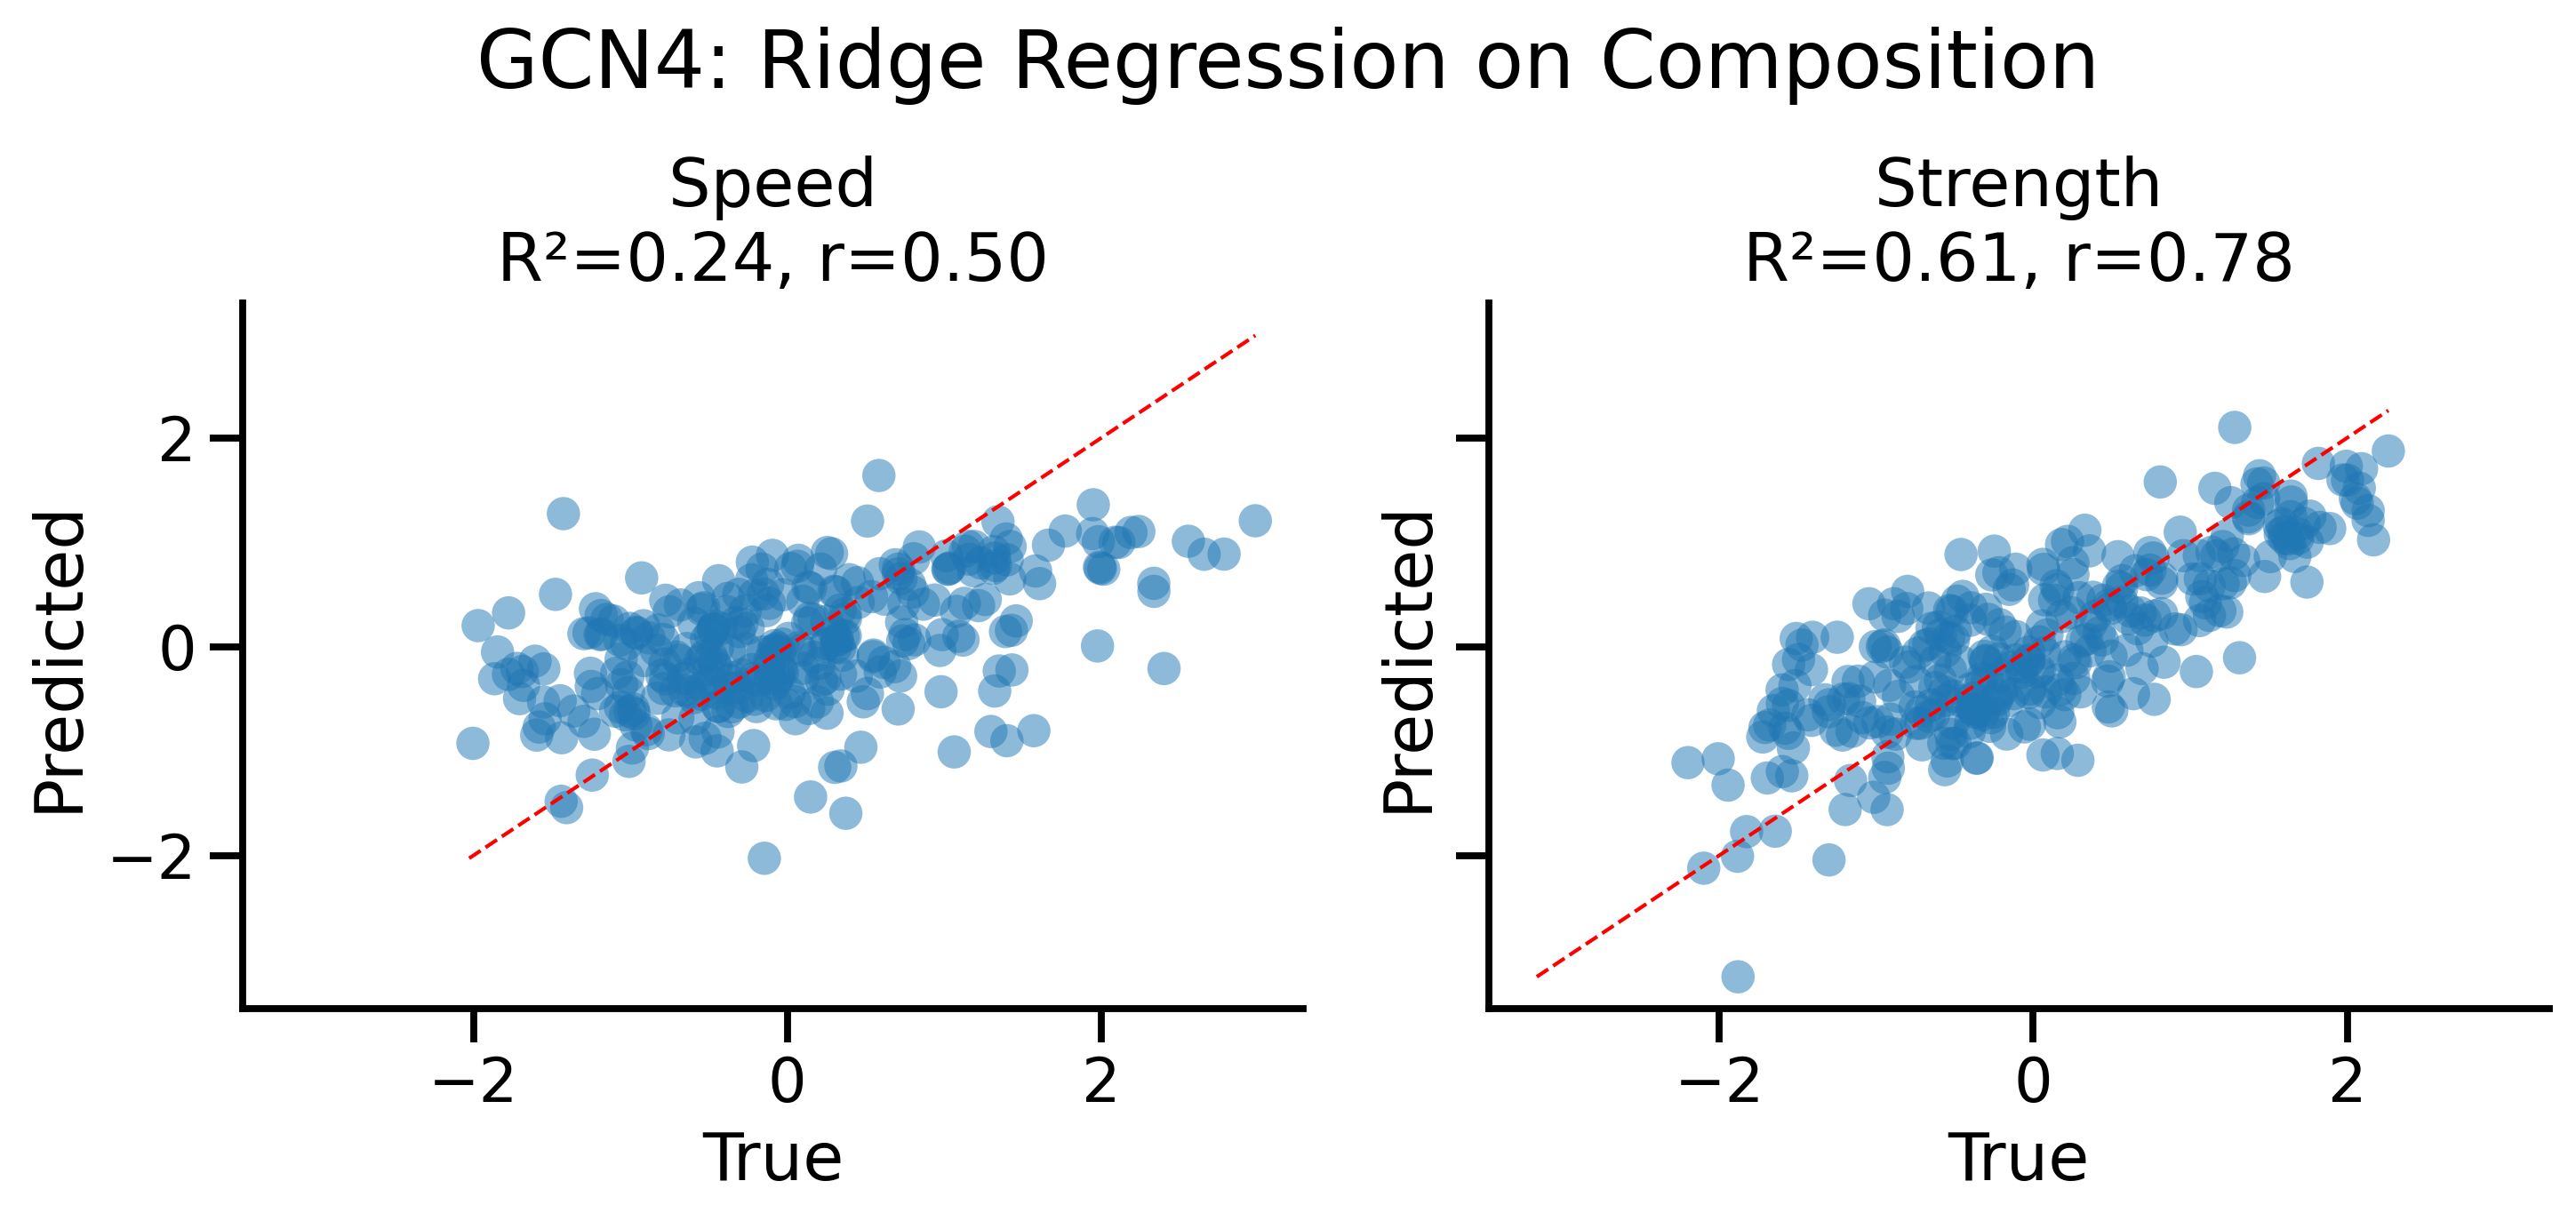

In [147]:
# =========================================================
# 4. Plot test-set predictions
# =========================================================
sns.set_context('talk')

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi = 300, sharey = True, sharex = True)

for ax, results, title in zip(
    axes,
    [speed_results, strength_results],
    ["Speed", "Strength"]
):
    y_true = results["y_test"]
    y_pred = results["y_test_pred"]

    ax.scatter(y_true, y_pred, alpha=0.5, edgecolors="none")
    lims = [
        min(np.min(y_true), np.min(y_pred)),
        max(np.max(y_true), np.max(y_pred))
    ]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    r = pearsonr(y_true, y_pred)[0]
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{title}\nR²={r2:.2f}, r={r:.2f}")

sns.despine()

fig.suptitle("GCN4: Ridge Regression on Composition", y = 0.93)
plt.tight_layout()
plt.show()

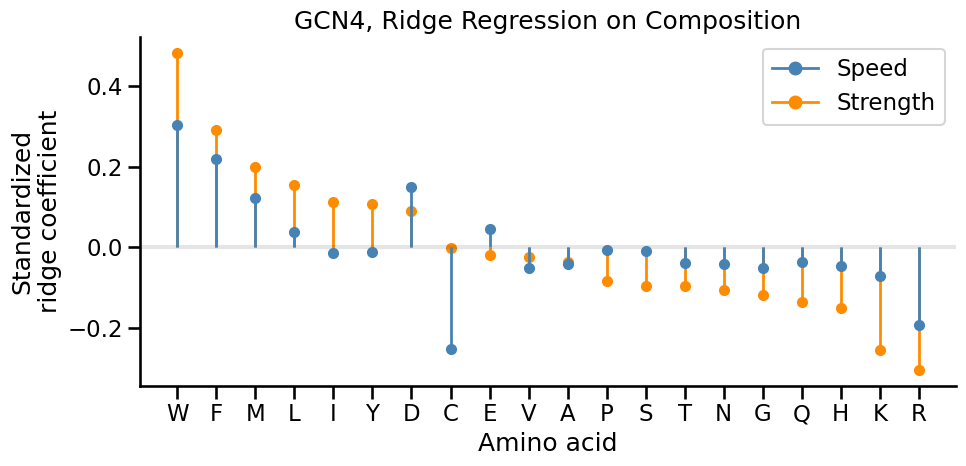

In [146]:
from matplotlib.lines import Line2D

speed_coef = speed_results["coef_df"].set_index("AA").loc[AMINO_ACIDS]["coef"]
strength_coef = strength_results["coef_df"].set_index("AA").loc[AMINO_ACIDS]["coef"]

coef_summary = pd.DataFrame({
    "speed": speed_coef,
    "strength": strength_coef
}, index=AMINO_ACIDS)

# Sort by strength coefficient
coef_summary = coef_summary.sort_values("strength", ascending=False)

x = np.arange(len(coef_summary))

plt.figure(figsize=(10, 5))

m1, s1, _ = plt.stem(
    x, coef_summary["speed"],
    linefmt="steelblue", markerfmt="o", basefmt=" "
)
plt.setp(s1, linewidth=2, color="steelblue", zorder = 10)
plt.setp(m1, markersize=7, markerfacecolor="steelblue", markeredgecolor="steelblue", zorder = 10)

m2, s2, _ = plt.stem(
    x, coef_summary["strength"],
    linefmt="darkorange", markerfmt="o", basefmt=" "
)
plt.setp(s2, linewidth=2, color="darkorange")
plt.setp(m2, markersize=7, markerfacecolor="darkorange", markeredgecolor="darkorange")

plt.axhline(0, color="black", lw=3, alpha = 0.1)
plt.xticks(x, coef_summary.index)
plt.xlabel("Amino acid")
plt.ylabel("Standardized\nridge coefficient")
plt.title("GCN4, Ridge Regression on Composition")

legend_elements = [
    Line2D([0], [0], color="steelblue", marker="o", lw=2, label="Speed"),
    Line2D([0], [0], color="darkorange", marker="o", lw=2, label="Strength"),
]
plt.legend(handles=legend_elements)

plt.tight_layout()
sns.despine()
plt.show()

Pearson r: 0.8005707551858456


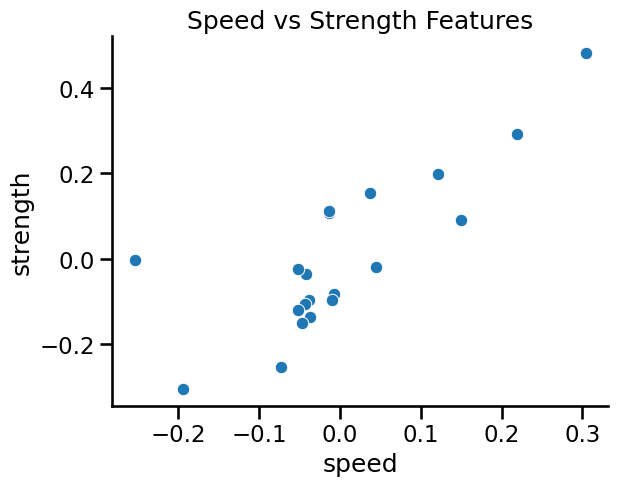

In [116]:
sns.scatterplot(data = coef_summary, x = "speed", y = "strength")
print(f'Pearson r: {pearsonr(coef_summary["speed"], coef_summary["strength"])[0]}')
plt.title("Speed vs Strength Features")
sns.despine()

## Bootstrap estimation of ridge coefficient uncertainty

This function estimates the uncertainty of the ridge regression coefficients using **bootstrap resampling**. In each iteration, the dataset is resampled with replacement, the ridge regularization strength (`alpha`) is reselected by cross-validation, and the model is refit. The fitted coefficients from all bootstrap samples are then collected.

For each amino acid feature, the bootstrap results are summarized by the **mean coefficient**, **standard deviation**, and **95% bootstrap interval**. Because `alpha` is re-estimated in every bootstrap sample, these intervals reflect both variability in the data and variability in model tuning, providing a practical measure of coefficient stability.

In [133]:
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import RidgeCV

def bootstrap_ridge_coefficients(X, y, feature_names, n_boot=50, random_state=42, alphas=None):
    rng = np.random.RandomState(random_state)

    if alphas is None:
        alphas = np.logspace(-3, 3, 50)

    X_array = np.asarray(X)
    y_array = np.asarray(y)

    coefs = []
    chosen_alphas = []

    for i in tqdm.tqdm(range(n_boot)):
        idx = rng.choice(len(y_array), size=len(y_array), replace=True)
        X_boot = X_array[idx]
        y_boot = y_array[idx]

        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_boot, y_boot)

        coefs.append(model.coef_)
        chosen_alphas.append(model.alpha_)

    coefs = np.array(coefs)

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "mean_coef": coefs.mean(axis=0),
        "std_coef": coefs.std(axis=0),
        "lower_95": np.percentile(coefs, 2.5, axis=0),
        "upper_95": np.percentile(coefs, 97.5, axis=0),
    })

    alpha_summary = {
        "mean_alpha": np.mean(chosen_alphas),
        "median_alpha": np.median(chosen_alphas),
        "alphas": chosen_alphas
    }

    return coef_df, alpha_summary

In [134]:
feature_names = AMINO_ACIDS

y_speed_z = (y_speed - y_speed.mean()) / y_speed.std()
y_strength_z = (y_strength - y_strength.mean()) / y_strength.std()

speed_boot_df, speed_alpha = bootstrap_ridge_coefficients(X, y_speed_z, feature_names)
strength_boot_df, strength_alpha = bootstrap_ridge_coefficients(X, y_strength_z, feature_names)

100%|██████████| 50/50 [00:26<00:00,  1.86it/s]


In [149]:
coef_summary = pd.DataFrame({
    "speed": speed_boot_df.set_index("feature")["mean_coef"],
    "speed_lo": speed_boot_df.set_index("feature")["lower_95"],
    "speed_hi": speed_boot_df.set_index("feature")["upper_95"],
    "strength": strength_boot_df.set_index("feature")["mean_coef"],
    "strength_lo": strength_boot_df.set_index("feature")["lower_95"],
    "strength_hi": strength_boot_df.set_index("feature")["upper_95"],
}).loc[AMINO_ACIDS]

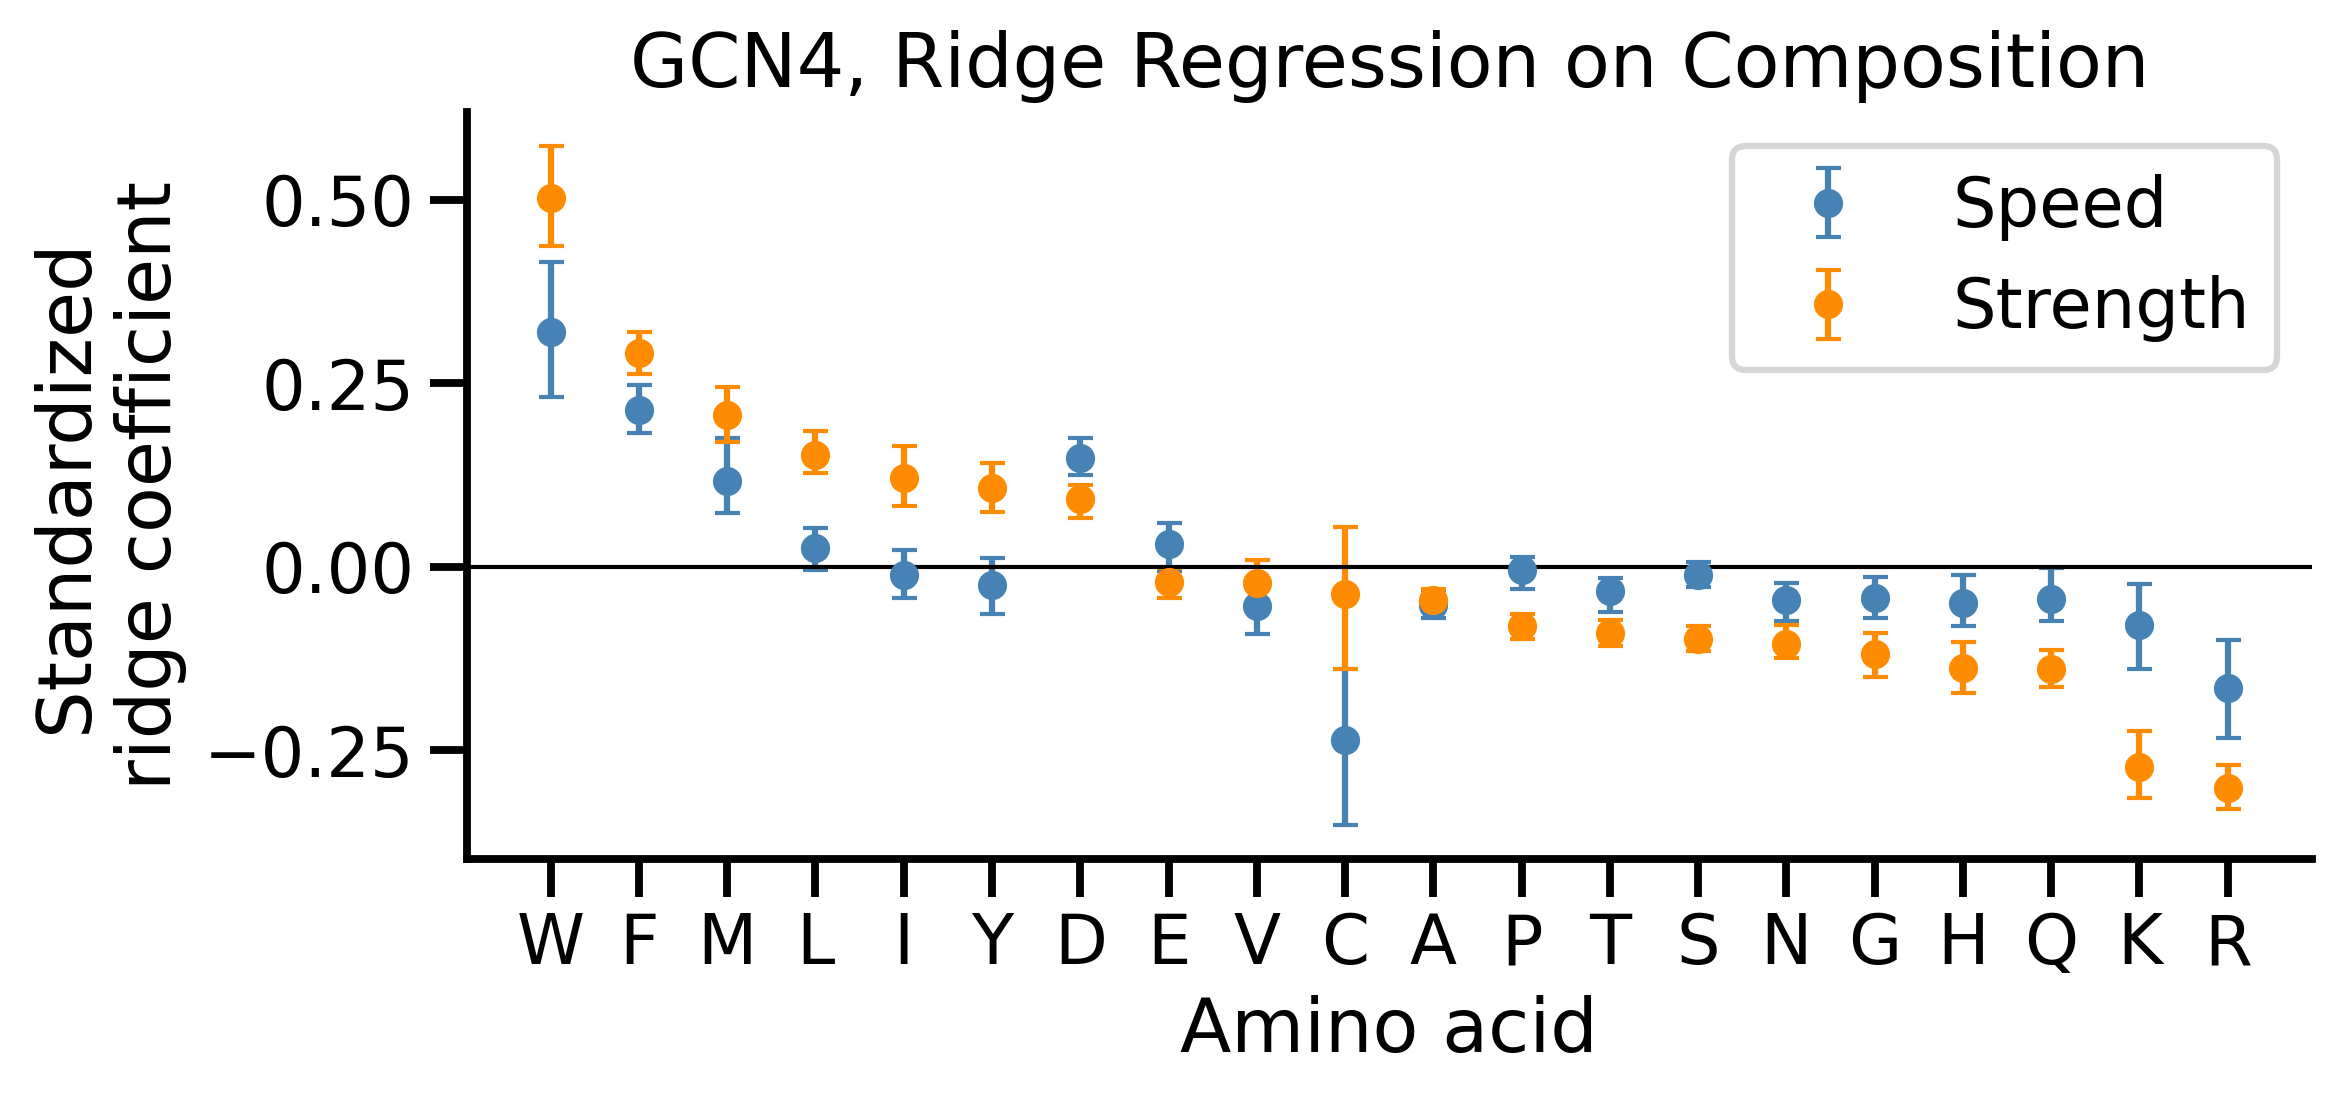

In [153]:
from matplotlib.lines import Line2D

coef_summary = coef_summary.sort_values("strength", ascending=False)
x = np.arange(len(coef_summary))

plt.figure(figsize=(8, 4),dpi = 300)

# Speed points + error bars
plt.errorbar(
    x,
    coef_summary["speed"],
    yerr=[
        coef_summary["speed"] - coef_summary["speed_lo"],
        coef_summary["speed_hi"] - coef_summary["speed"]
    ],
    fmt="o",
    color="steelblue",
    ecolor="steelblue",
    elinewidth=1.5,
    capsize=3,
    markersize=6,
    label="Speed"
)

# Strength points + error bars
plt.errorbar(
    x,
    coef_summary["strength"],
    yerr=[
        coef_summary["strength"] - coef_summary["strength_lo"],
        coef_summary["strength_hi"] - coef_summary["strength"]
    ],
    fmt="o",
    color="darkorange",
    ecolor="darkorange",
    elinewidth=1.5,
    capsize=3,
    markersize=6,
    label="Strength"
)

plt.axhline(0, color="black", lw=1)
plt.xticks(x, coef_summary.index)
plt.xlabel("Amino acid")
plt.ylabel("Standardized\nridge coefficient")
plt.title("GCN4, Ridge Regression on Composition")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Position-specific linear regression on sequence identity

This analysis tests whether **amino acid identity at individual sequence positions** can predict the measured **speed** and **strength** of each sequence. Instead of using overall amino acid composition, each sequence is represented by a **position-by-position one-hot encoding**, where each position is expanded into 20 binary features indicating which amino acid is present. This allows the model to learn **position-specific effects**, rather than only global composition trends.

A separate **linear regression** model is then fit for speed and strength. Model performance is evaluated using both an **80/20 train-test split** and **5-fold cross-validation**, with performance reported as **R²**, **RMSE**, and **Pearson correlation**. The fitted coefficients are also ranked by absolute value to identify the sequence positions and amino acids with the strongest associations to each trait. Positive coefficients indicate residues at specific positions associated with higher predicted values, while negative coefficients indicate residues associated with lower predicted values.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# =========================================================
# 1. One-hot encode sequences position by position
# =========================================================
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

seqs = exponential_fit["ADseq"].tolist()
seq_length = len(seqs[0])

# Check equal length
assert all(len(seq) == seq_length for seq in seqs), "Sequences must all have the same length"

def one_hot_sequence(seq):
    arr = np.zeros((seq_length, len(AMINO_ACIDS)), dtype=int)
    for pos, aa in enumerate(seq):
        if aa in aa_to_idx:
            arr[pos, aa_to_idx[aa]] = 1
        else:
            raise ValueError(f"Unexpected amino acid '{aa}' in sequence: {seq}")
    return arr.flatten()

X = np.array([one_hot_sequence(seq) for seq in seqs])

y_speed = exponential_fit["speed"].values
y_strength = exponential_fit["strength"].values

# Optional readable feature names
feature_names = [
    f"pos{pos+1}_{aa}"
    for pos in range(seq_length)
    for aa in AMINO_ACIDS
]

# =========================================================
# 2. Helper function
# =========================================================
def evaluate_linear(X, y, target_name, feature_names):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    test_r, _ = pearsonr(y_test, y_test_pred)

    print(f"\n=== {target_name} ===")
    print(f"Test R^2:   {test_r2:.3f}")
    print(f"Test RMSE:  {test_rmse:.3f}")
    print(f"Test r:     {test_r:.3f}")

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": model.coef_
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    print("\nTop 15 coefficients by |value|:")
    print(coef_df.head(15)[["feature", "coef"]].to_string(index=False))

    # 5-fold CV predictions
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_cv_pred = cross_val_predict(LinearRegression(), X, y, cv=kf)

    cv_r2 = r2_score(y, y_cv_pred)
    cv_rmse = mean_squared_error(y, y_cv_pred) ** 0.5
    cv_r, _ = pearsonr(y, y_cv_pred)

    print("\n5-fold CV performance:")
    print(f"CV R^2:     {cv_r2:.3f}")
    print(f"CV RMSE:    {cv_rmse:.3f}")
    print(f"CV r:       {cv_r:.3f}")

    return {
        "model": model,
        "coef_df": coef_df,
        "X_test": X_test,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_cv_pred": y_cv_pred,
    }

# =========================================================
# 3. Run models
# =========================================================
speed_results = evaluate_linear(X, y_speed, "SPEED", feature_names)
strength_results = evaluate_linear(X, y_strength, "STRENGTH", feature_names)


=== SPEED ===
Test R^2:   -0.468
Test RMSE:  0.059
Test r:     0.345

Top 15 coefficients by |value|:
feature      coef
pos12_C -0.180792
pos16_C  0.115871
pos26_C  0.100021
pos23_C -0.071038
 pos9_C  0.065503
 pos1_C  0.065194
pos33_C -0.056294
pos16_W  0.049774
 pos7_C -0.049472
pos39_W  0.049438
pos13_C -0.048667
pos24_K -0.048301
pos35_W  0.047541
pos23_K  0.046823
pos38_C -0.044504

5-fold CV performance:
CV R^2:     -0.712
CV RMSE:    0.064
CV r:       0.298

=== STRENGTH ===
Test R^2:   0.338
Test RMSE:  0.984
Test r:     0.712

Top 15 coefficients by |value|:
feature      coef
pos16_C  3.266906
pos12_C -2.103320
pos23_C -1.803120
pos26_W  1.588220
pos13_W  1.212702
pos15_W  1.170995
pos29_W  1.126491
pos14_K -1.109165
pos20_C  1.054848
pos33_W  1.050076
pos26_K -1.039007
 pos3_W  0.963024
pos17_R -0.940789
 pos8_W  0.908100
pos14_W  0.898733

5-fold CV performance:
CV R^2:     0.157
CV RMSE:    1.087
CV r:       0.628


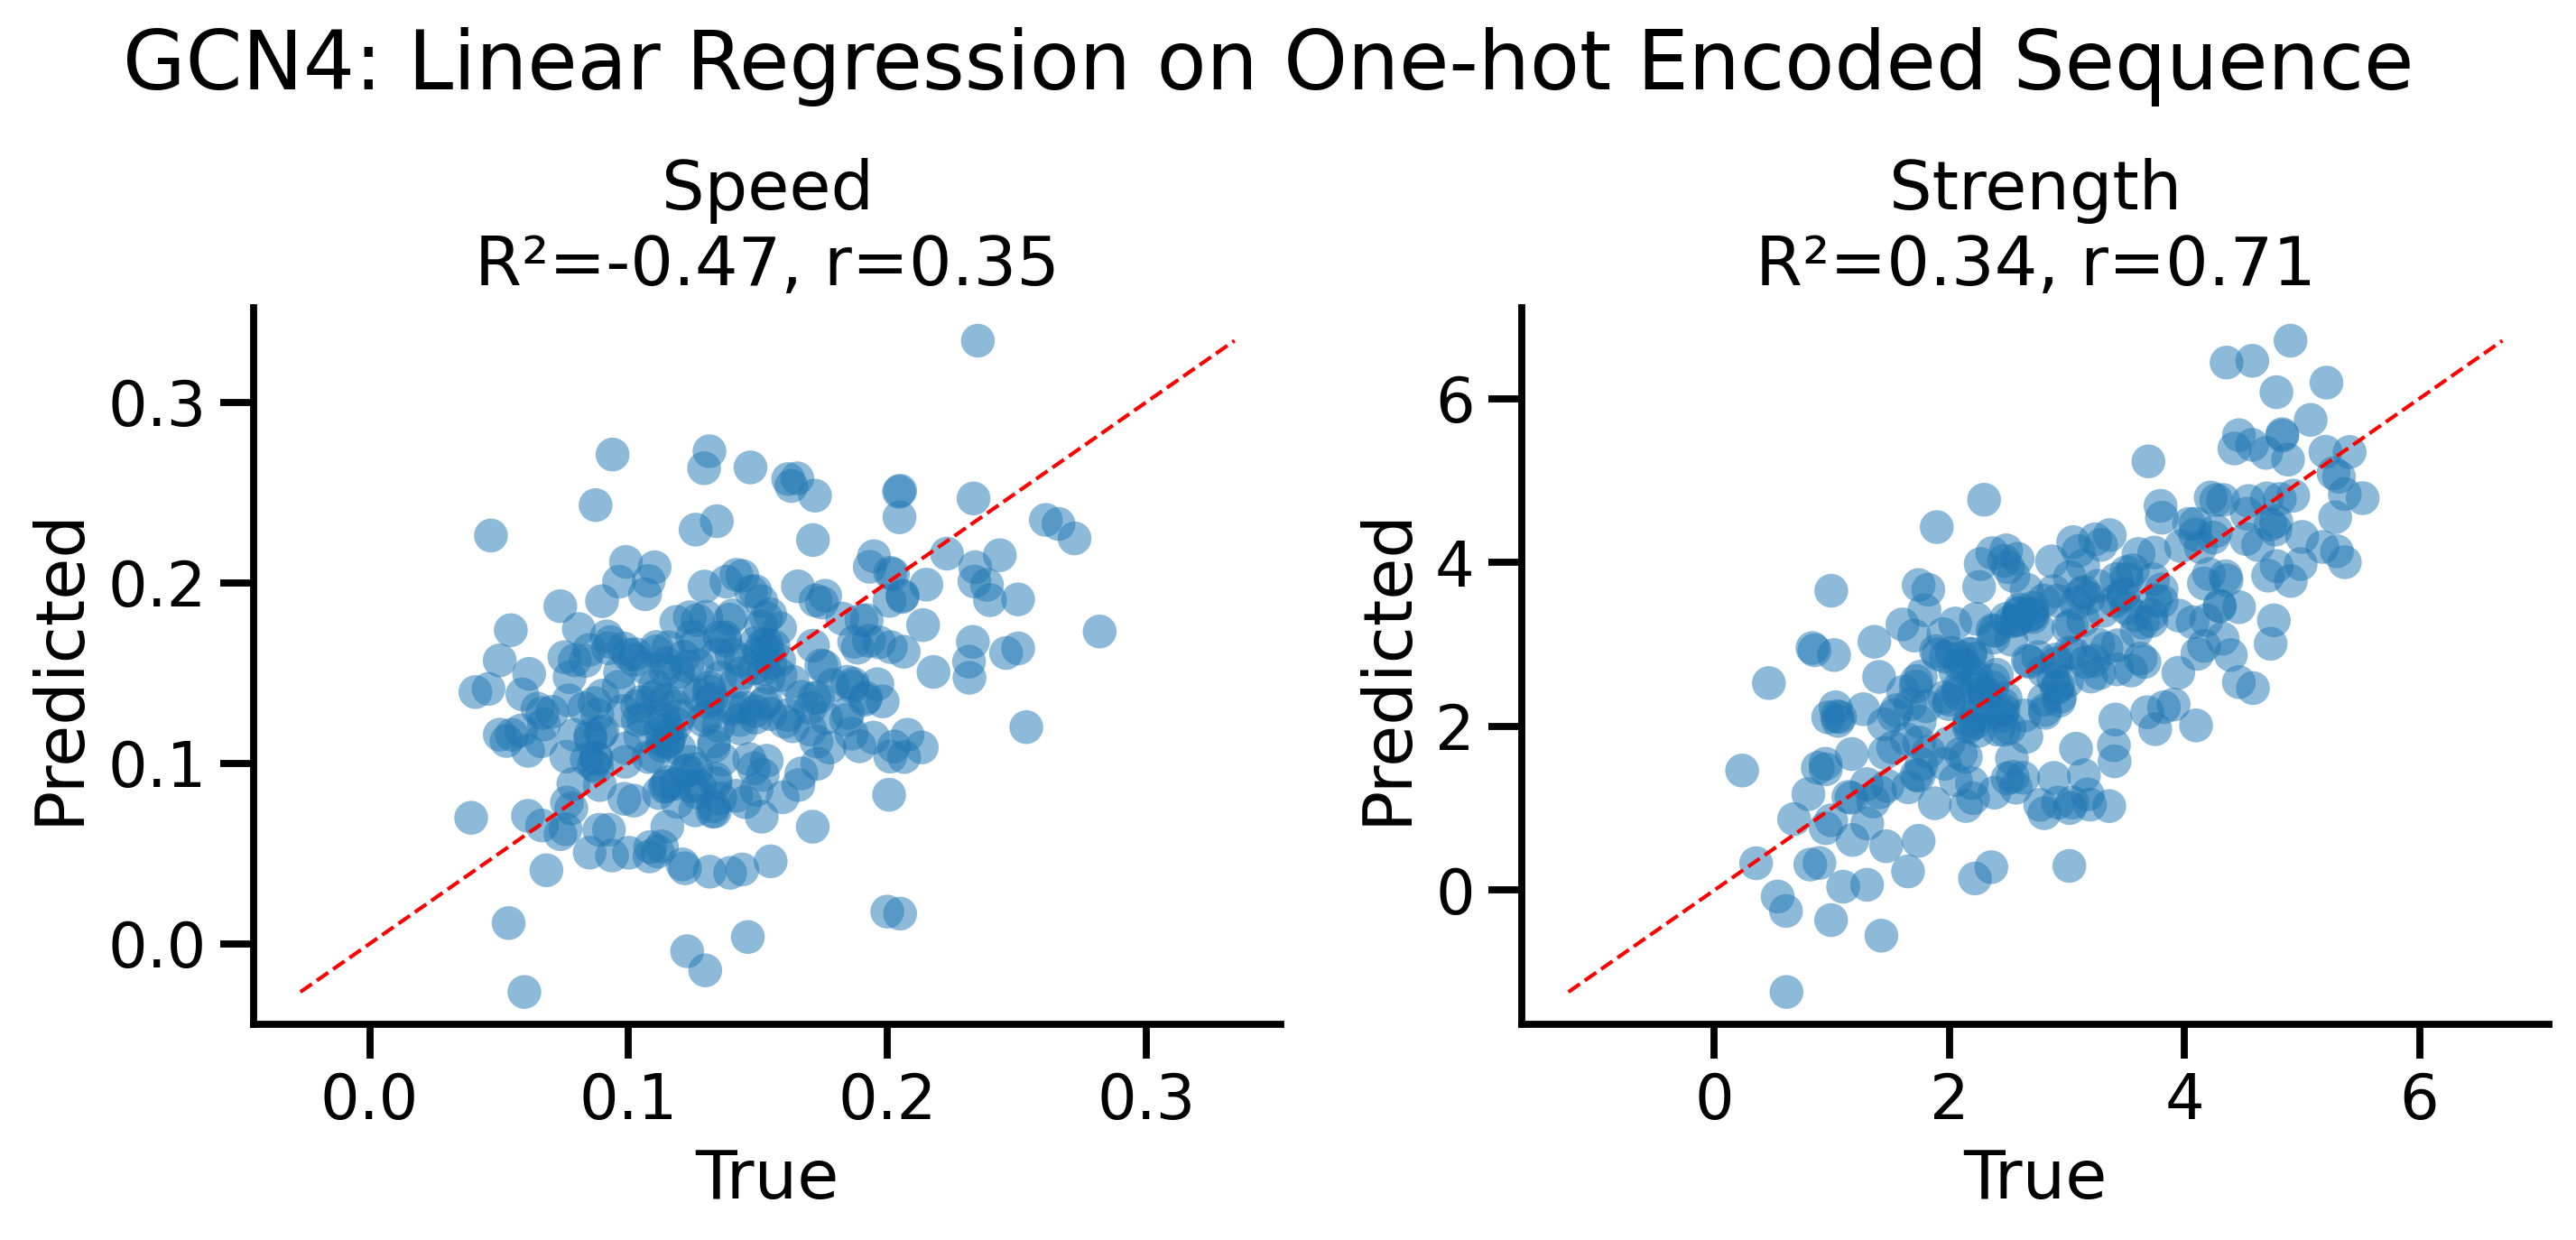

In [110]:
# =========================================================
# 4. Plot test-set predictions
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(10,5), dpi = 300)

for ax, results, title in zip(
    axes,
    [speed_results, strength_results],
    ["Speed", "Strength"]
):
    y_true = results["y_test"]
    y_pred = results["y_test_pred"]

    ax.scatter(y_true, y_pred, alpha=0.5, edgecolors="none")
    lims = [
        min(np.min(y_true), np.min(y_pred)),
        max(np.max(y_true), np.max(y_pred))
    ]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    r = pearsonr(y_true, y_pred)[0]
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{title}\nR²={r2:.2f}, r={r:.2f}")

sns.despine()
plt.suptitle("GCN4: Linear Regression on One-hot Encoded Sequence", y = 0.93)
plt.tight_layout()
plt.show()


── SPEED ──────────────────────
  R²  (test): 0.140
  r   (test): 0.398

  Top 5 AAs by |coefficient|:
AA       coef
 C  73.788777
 D -27.004973
 F -26.491462
 R  24.451655
 W -18.662832

── STRENGTH ──────────────────────
  R²  (test): 0.614
  r   (test): 0.784

  Top 5 AAs by |coefficient|:
AA       coef
 W  23.979941
 R -14.715285
 F  14.040271
 K -12.453091
 M   9.632442


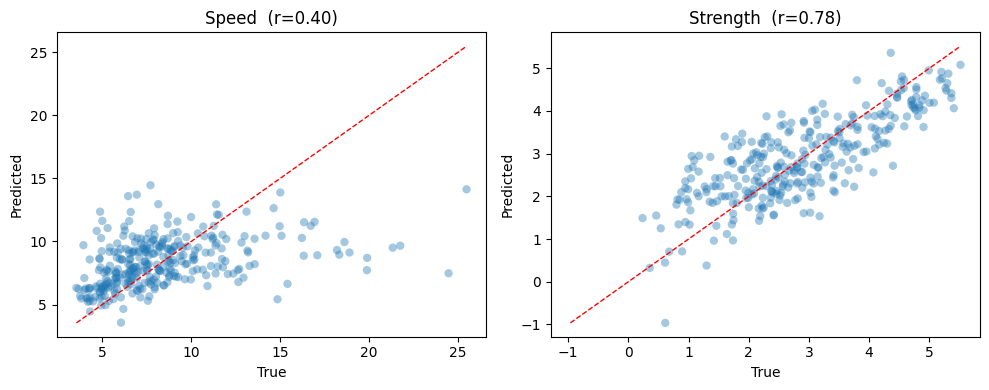

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# ── 1. Build AA composition features ──────────────────────────────────────────
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_composition(seq):
    """Return fractional count of each AA in the sequence."""
    length = len(seq)
    return {aa: seq.count(aa) / length for aa in AMINO_ACIDS}

comp_df = pd.DataFrame(
    exponential_fit["ADseq"].apply(aa_composition).tolist()
)

# ── 2. Assemble X, y ──────────────────────────────────────────────────────────
X = comp_df.values                          # shape (1557, 20)
y_speed    = exponential_fit["speed"].values
y_strength = exponential_fit["strength"].values

# ── 3. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, ys_train, ys_test, ystr_train, ystr_test = train_test_split(
    X, y_speed, y_strength, test_size=0.2, random_state=42
)

# ── 4. Fit & evaluate ─────────────────────────────────────────────────────────
def fit_and_report(X_train, X_test, y_train, y_test, target_name):
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    r, _ = pearsonr(y_test, y_pred)
    
    print(f"\n── {target_name} ──────────────────────")
    print(f"  R²  (test): {r2:.3f}")
    print(f"  r   (test): {r:.3f}")
    
    # Top contributing AAs
    coef_df = pd.DataFrame({
        "AA": AMINO_ACIDS,
        "coef": model.coef_
    }).sort_values("coef", key=abs, ascending=False)
    print(f"\n  Top 5 AAs by |coefficient|:")
    print(coef_df.head(5).to_string(index=False))
    
    return model, y_pred

model_speed,    pred_speed    = fit_and_report(X_train, X_test, ys_train,   ys_test,   "SPEED")
model_strength, pred_strength = fit_and_report(X_train, X_test, ystr_train, ystr_test, "STRENGTH")

# ── 5. Optional: quick scatter plot ───────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [ys_test, ystr_test],
    [pred_speed, pred_strength],
    ["Speed", "Strength"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted")
    ax.set_title(f"{title}  (r={pearsonr(y_true, y_pred)[0]:.2f})")

plt.tight_layout()
plt.show()

Sequence lengths: min=40, max=40, mean=40.0
Feature matrix shape: (1557, 800)

── SPEED ──────────────────────
  R²  (test): -0.943
  r   (test): 0.230
  Top 5 most important positions (0-indexed): [11, 1, 6, 7, 14]

── STRENGTH ──────────────────────
  R²  (test): 0.338
  r   (test): 0.712
  Top 5 most important positions (0-indexed): [15, 25, 14, 11, 13]


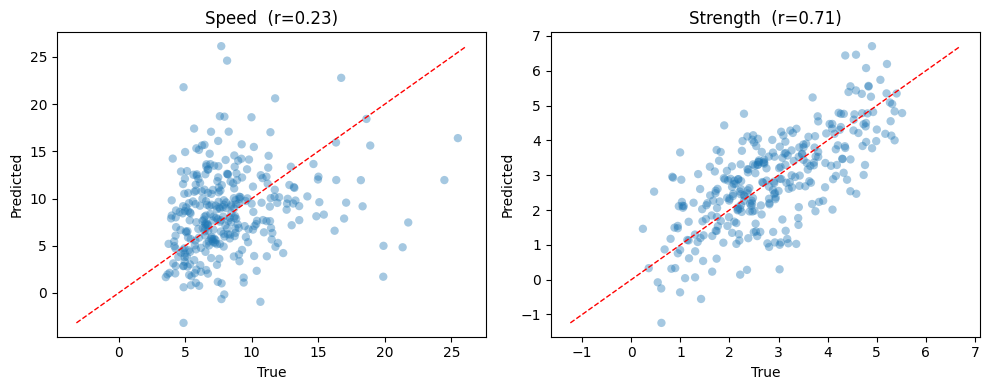

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# ── 1. One-hot encode sequences ───────────────────────────────────────────────
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_IDX   = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def one_hot_encode(seq):
    """Flatten a (seq_len x 20) one-hot matrix into a 1D vector."""
    matrix = np.zeros((len(seq), 20), dtype=np.float32)
    for i, aa in enumerate(seq):
        if aa in AA_TO_IDX:
            matrix[i, AA_TO_IDX[aa]] = 1.0
    return matrix.flatten()

# Check all sequences are the same length
lengths = exponential_fit["ADseq"].str.len()
print(f"Sequence lengths: min={lengths.min()}, max={lengths.max()}, mean={lengths.mean():.1f}")

# Encode — produces shape (n_seqs, seq_len * 20)
X = np.stack(exponential_fit["ADseq"].apply(one_hot_encode).values)
print(f"Feature matrix shape: {X.shape}")

# ── 2. Targets ────────────────────────────────────────────────────────────────
y_speed    = exponential_fit["speed"].values
y_strength = exponential_fit["strength"].values

# ── 3. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, ys_train, ys_test, ystr_train, ystr_test = train_test_split(
    X, y_speed, y_strength, test_size=0.2, random_state=42
)

# ── 4. Fit & evaluate ─────────────────────────────────────────────────────────
def fit_and_report(X_train, X_test, y_train, y_test, target_name, seq_len):
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2     = r2_score(y_test, y_pred)
    r, _   = pearsonr(y_test, y_pred)

    print(f"\n── {target_name} ──────────────────────")
    print(f"  R²  (test): {r2:.3f}")
    print(f"  r   (test): {r:.3f}")

    # Reshape coefficients to (seq_len, 20) to find important positions
    coef_matrix = model.coef_.reshape(seq_len, 20)
    pos_importance = np.abs(coef_matrix).sum(axis=1)  # sum over AAs per position

    top_positions = np.argsort(pos_importance)[::-1][:5]
    print(f"  Top 5 most important positions (0-indexed): {top_positions.tolist()}")

    return model, y_pred

seq_len = lengths.max()

model_speed,    pred_speed    = fit_and_report(X_train, X_test, ys_train,   ys_test,   "SPEED",    seq_len)
model_strength, pred_strength = fit_and_report(X_train, X_test, ystr_train, ystr_test, "STRENGTH", seq_len)

# ── 5. Scatter plots ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [ys_test, ystr_test],
    [pred_speed, pred_strength],
    ["Speed", "Strength"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted")
    ax.set_title(f"{title}  (r={pearsonr(y_true, y_pred)[0]:.2f})")

plt.tight_layout()
plt.show()


── SPEED ──────────────────────
  Best alpha : 2682.7
  R²  (test) : 0.074
  r   (test) : 0.286
  Top 5 positions: [11, 1, 14, 9, 6]

── STRENGTH ──────────────────────
  Best alpha : 655.1
  R²  (test) : 0.471
  r   (test) : 0.694
  Top 5 positions: [13, 14, 24, 28, 19]


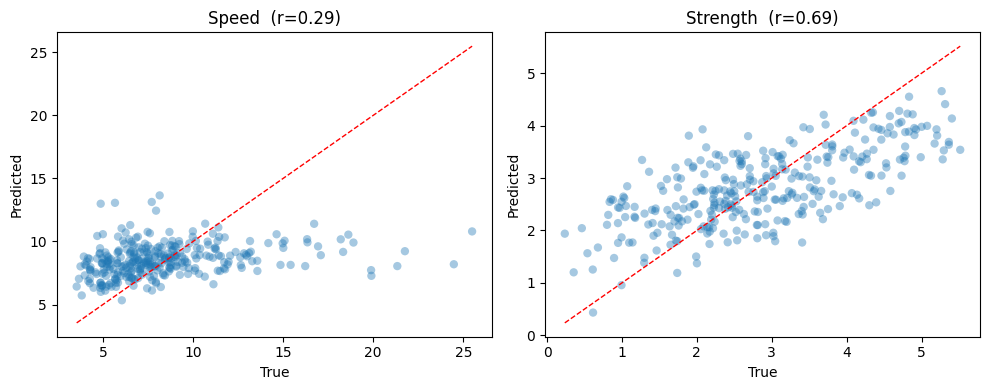

In [8]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

# ── Ridge with cross-validated alpha selection ────────────────────────────────
alphas = np.logspace(0, 6, 50)  # search 1 → 1,000,000

def fit_ridge(X_train, X_test, y_train, y_test, target_name, seq_len):
    # Scale + RidgeCV in a pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge",  RidgeCV(alphas=alphas, cv=5))
    ])
    pipe.fit(X_train, y_train)

    best_alpha = pipe.named_steps["ridge"].alpha_
    y_pred     = pipe.predict(X_test)
    r2         = r2_score(y_test, y_pred)
    r, _       = pearsonr(y_test, y_pred)

    print(f"\n── {target_name} ──────────────────────")
    print(f"  Best alpha : {best_alpha:.1f}")
    print(f"  R²  (test) : {r2:.3f}")
    print(f"  r   (test) : {r:.3f}")

    # Position importance
    coef_matrix    = pipe.named_steps["ridge"].coef_.reshape(seq_len, 20)
    pos_importance = np.abs(coef_matrix).sum(axis=1)
    top_pos        = np.argsort(pos_importance)[::-1][:5]
    print(f"  Top 5 positions: {top_pos.tolist()}")

    return pipe, y_pred

model_speed,    pred_speed    = fit_ridge(X_train, X_test, ys_train,   ys_test,   "SPEED",    40)
model_strength, pred_strength = fit_ridge(X_train, X_test, ystr_train, ystr_test, "STRENGTH", 40)

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [ys_test, ystr_test],
    [pred_speed, pred_strength],
    ["Speed", "Strength"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted")
    ax.set_title(f"{title}  (r={pearsonr(y_true, y_pred)[0]:.2f})")
plt.tight_layout()
plt.show()


── SPEED (log) ──────────────────────
  Best alpha : 91.0
  R²  (test) : 0.120
  r   (test) : 0.380

── STRENGTH ──────────────────────
  Best alpha : 16.8
  R²  (test) : 0.615
  r   (test) : 0.784


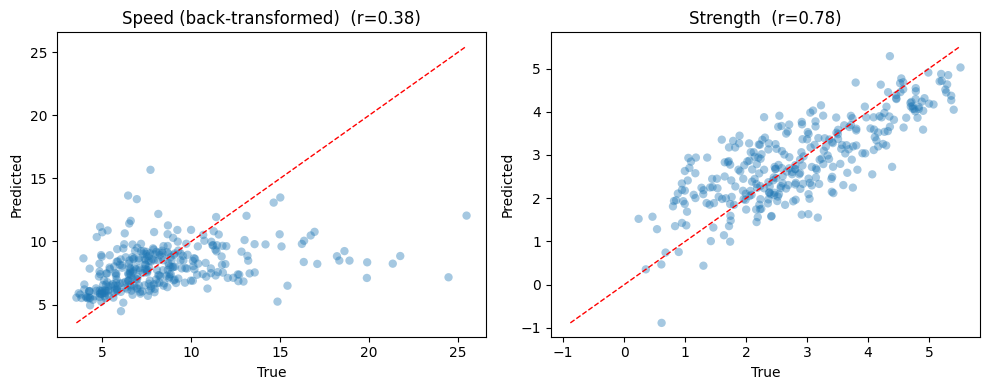

In [27]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ── Features & targets ────────────────────────────────────────────────────────
X_comp         = comp_df.values                          # ← this was missing
y_speed_log    = np.log(exponential_fit["speed"].values)
y_strength     = exponential_fit["strength"].values

X_train, X_test, ys_train, ys_test, ystr_train, ystr_test = train_test_split(
    X_comp, y_speed_log, y_strength, test_size=0.2, random_state=42
)

alphas = np.logspace(0, 6, 50)

def fit_ridge(X_train, X_test, y_train, y_test, target_name, log_target=False):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge",  RidgeCV(alphas=alphas, cv=5))
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if log_target:
        y_test_bt = np.exp(y_test)
        y_pred_bt = np.exp(y_pred)
    else:
        y_test_bt, y_pred_bt = y_test, y_pred

    r2   = r2_score(y_test_bt, y_pred_bt)
    r, _ = pearsonr(y_test_bt, y_pred_bt)

    print(f"\n── {target_name} ──────────────────────")
    print(f"  Best alpha : {pipe.named_steps['ridge'].alpha_:.1f}")
    print(f"  R²  (test) : {r2:.3f}")
    print(f"  r   (test) : {r:.3f}")

    return pipe, y_pred_bt, y_test_bt

model_speed,    pred_speed,    true_speed = fit_ridge(X_train, X_test, ys_train,   ys_test,   "SPEED (log)",  log_target=True)
model_strength, pred_strength, true_str   = fit_ridge(X_train, X_test, ystr_train, ystr_test, "STRENGTH",     log_target=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_true, y_pred, title in zip(
    axes,
    [true_speed, true_str],
    [pred_speed, pred_strength],
    ["Speed (back-transformed)", "Strength"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True"); ax.set_ylabel("Predicted")
    ax.set_title(f"{title}  (r={pearsonr(y_true, y_pred)[0]:.2f})")
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# ── Physicochemical feature table ─────────────────────────────────────────────
props = {
#              hydro   charge  size    polar   arom
'A': dict(hydro=1.8,  charge= 0, mw= 89, polar=0, arom=0),
'C': dict(hydro=2.5,  charge= 0, mw=121, polar=0, arom=0),
'D': dict(hydro=-3.5, charge=-1, mw=133, polar=1, arom=0),
'E': dict(hydro=-3.5, charge=-1, mw=147, polar=1, arom=0),
'F': dict(hydro=2.8,  charge= 0, mw=165, polar=0, arom=1),
'G': dict(hydro=-0.4, charge= 0, mw= 75, polar=0, arom=0),
'H': dict(hydro=-3.2, charge= 0, mw=155, polar=1, arom=1),
'I': dict(hydro=4.5,  charge= 0, mw=131, polar=0, arom=0),
'K': dict(hydro=-3.9, charge= 1, mw=146, polar=1, arom=0),
'L': dict(hydro=3.8,  charge= 0, mw=131, polar=0, arom=0),
'M': dict(hydro=1.9,  charge= 0, mw=149, polar=0, arom=0),
'N': dict(hydro=-3.5, charge= 0, mw=132, polar=1, arom=0),
'P': dict(hydro=-1.6, charge= 0, mw=115, polar=0, arom=0),
'Q': dict(hydro=-3.5, charge= 0, mw=146, polar=1, arom=0),
'R': dict(hydro=-4.5, charge= 1, mw=174, polar=1, arom=0),
'S': dict(hydro=-0.8, charge= 0, mw=105, polar=1, arom=0),
'T': dict(hydro=-0.7, charge= 0, mw=119, polar=1, arom=0),
'V': dict(hydro=4.2,  charge= 0, mw=117, polar=0, arom=0),
'W': dict(hydro=-0.9, charge= 0, mw=204, polar=0, arom=1),
'Y': dict(hydro=-1.3, charge= 0, mw=181, polar=1, arom=1),
}

def physchem_features(seq):
    h  = [props[aa]['hydro']  for aa in seq if aa in props]
    c  = [props[aa]['charge'] for aa in seq if aa in props]
    mw = [props[aa]['mw']     for aa in seq if aa in props]
    ar = [props[aa]['arom']   for aa in seq if aa in props]
    po = [props[aa]['polar']  for aa in seq if aa in props]
    n  = len(seq)

    return {
        # Global summaries
        'mean_hydro':    np.mean(h),
        'std_hydro':     np.std(h),
        'max_hydro':     np.max(h),
        'min_hydro':     np.min(h),
        'net_charge':    sum(c),
        'charge_density':sum(c) / n,
        'frac_aromatic': sum(ar) / n,
        'frac_polar':    sum(po) / n,
        'mean_mw':       np.mean(mw),
        # N-term vs C-term (first/last 10 AAs)
        'hydro_Nterm':   np.mean(h[:10]),
        'hydro_Cterm':   np.mean(h[-10:]),
        'hydro_asymmetry': np.mean(h[:10]) - np.mean(h[-10:]),
        'charge_Nterm':  sum(c[:10]),
        'charge_Cterm':  sum(c[-10:]),
        # Patterning
        'hydro_autocorr': np.corrcoef(h[:-1], h[1:])[0,1],  # neighbour similarity
        'charge_runs':   sum(1 for i in range(1,len(c)) if c[i]==c[i-1]),  # same-charge runs
    }

feat_df = pd.DataFrame(
    exponential_fit["ADseq"].apply(physchem_features).tolist()
)
print(feat_df.shape)
print(feat_df.head())

# ── Fit with Lasso ────────────────────────────────────────────────────────────
X  = feat_df.values
y_speed_log = np.log(exponential_fit["speed"].values)
y_strength  = exponential_fit["strength"].values

X_train, X_test, ys_train, ys_test, ystr_train, ystr_test = train_test_split(
    X, y_speed_log, y_strength, test_size=0.2, random_state=42
)

def fit_lasso(X_train, X_test, y_train, y_test, feature_names, target_name, log_target=False):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso",  LassoCV(cv=5, max_iter=10000))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if log_target:
        y_test, y_pred = np.exp(y_test), np.exp(y_pred)

    r, _  = pearsonr(y_test, y_pred)
    r2    = r2_score(y_test, y_pred)

    # Sparse coefficients — only non-zero ones
    coefs = pipe.named_steps["lasso"].coef_
    coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
    coef_df = coef_df[coef_df["coef"] != 0].sort_values("coef", key=abs, ascending=False)

    print(f"\n── {target_name} ──────────────────────")
    print(f"  r  (test): {r:.3f}   R²: {r2:.3f}")
    print(f"  Non-zero features ({len(coef_df)}/{len(feature_names)}):")
    print(coef_df.to_string(index=False))

    return pipe, coef_df

pipe_speed,    coef_speed    = fit_lasso(X_train, X_test, ys_train,   ys_test,
                                          feat_df.columns, "SPEED",    log_target=True)
pipe_strength, coef_strength = fit_lasso(X_train, X_test, ystr_train, ystr_test,
                                          feat_df.columns, "STRENGTH", log_target=False)

(1557, 16)
   mean_hydro  std_hydro  max_hydro  min_hydro  net_charge  charge_density  \
0     -0.0975   2.660309        4.5       -3.5          -4           -0.10   
1      0.3350   2.319219        4.2       -3.5          -6           -0.15   
2     -0.0225   2.506740        4.2       -3.5          -6           -0.15   
3      0.1750   2.475858        4.5       -3.5          -6           -0.15   
4     -0.3100   2.588223        4.5       -3.9          -4           -0.10   

   frac_aromatic  frac_polar  mean_mw  hydro_Nterm  hydro_Cterm  \
0          0.125       0.475  120.825        -0.54        -0.16   
1          0.125       0.450  113.700        -0.03         0.38   
2          0.125       0.500  119.275        -0.03        -0.71   
3          0.125       0.425  116.675        -0.12        -0.10   
4          0.100       0.450  123.525        -0.88        -0.50   

   hydro_asymmetry  charge_Nterm  charge_Cterm  hydro_autocorr  charge_runs  
0            -0.38            -1       